# Importance value Index

## Foreword

## 1. Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from inventory_data import load_inventory

## 2. Import data

In [ ]:
# Load an Excel file
df = df = load_inventory()

## 3. Data tidying

In [25]:
#Data are divided according to line number
line1 = df[df["Line Number"] == 1]
line2 = df[df["Line Number"] == 2]
line3 = df[df["Line Number"] == 3]
line4 = df[df["Line Number"] == 4]
line5 = df[df["Line Number"] == 5]
line6 = df[df["Line Number"] == 6]
line7 = df[df["Line Number"] == 7]

## 4. Importance Value Index (IVI)

In [26]:
dict_ivi = {
    "Fr": "Relative Frequency",
    "Do": "Relative Dominance", 
    "Ab": "Relative Abundance",
}

color_ivi = {
    "Fr": "#1f77b4",   
    "Do": "#be2f2f",
    "Ab": "#58dd58",
    }

### 4.1 Frequency

In [27]:
# Create the frequency table for line 1 - count of unique Plots per Scientific name
fr1 = line1.pivot_table(
    index='Scientific name',      # Group by Scientific name
    values='Plot',     # Count unique plots
    aggfunc='nunique'       # Count unique values in each group
)

fr1 = fr1[fr1['Plot'] > 0]

fr1.sort_values(by='Plot', ascending=False)

# Count unique plots in line1
pl1 = line1['Plot'].nunique()

print("The number of unique plots in line 1 is:", pl1)

The number of unique plots in line 1 is: 12


C:\Users\migue\AppData\Local\Temp\ipykernel_12580\4001647843.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  fr1 = line1.pivot_table(


In [28]:
fr1["Freq"] = (fr1["Plot"] / pl1) * 100

fr1.sort_values(by='Freq', ascending=False)

freq1 = fr1['Freq'].sum()
print(f"The total frequency in line 1 is: {freq1}")

fr1["Fr"] = (fr1["Freq"] / freq1) * 100

fr1.sort_values(by='Fr', ascending=False)

The total frequency in line 1 is: 2883.333333333333


,Plot,Freq,Fr
Scientific name,,,
nn,11,91.666667,3.179191
Pouteria sp,11,91.666667,3.179191
Prioria sp,11,91.666667,3.179191
Anacardium excelsum,11,91.666667,3.179191
Pterocarpus officinalis,11,91.666667,3.179191
...,...,...,...
Mabea sp,1,8.333333,0.289017
Maquira sp,1,8.333333,0.289017
Platypodium elegans,1,8.333333,0.289017


### 4.2 Dominance

In [29]:
# Create the dominance table for line 1
do1 = line1.pivot_table(
    index='Scientific name',      # The categories you want to count
    values='Basal area [m2]',     # The column you are counting
    aggfunc='sum'       # The action: sum the values in each group
)

do1 = do1[do1['Basal area [m2]'] != 0]

do1.sort_values(by='Basal area [m2]', ascending=False)

g1 = do1['Basal area [m2]'].sum()
print(f"The total basal area in line 1 is: {g1} m2")

do1["Do"] = (do1["Basal area [m2]"] / g1) * 100

do1.sort_values(by='Do', ascending=False)

The total basal area in line 1 is: 219.7045474648995 m2


C:\Users\migue\AppData\Local\Temp\ipykernel_12580\3297962775.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  do1 = line1.pivot_table(


,Basal area [m2],Do
Scientific name,,
Prioria copaifera,28.932947,13.169025
Anacardium excelsum,17.725720,8.067981
Pouteria sp,13.427027,6.111402
Ficus glabrata,13.069839,5.948825
Pterocarpus officinalis,12.101714,5.508176
...,...,...
Luehea seemannii,0.030065,0.013685
Ceiba pentandra,0.025288,0.011510
Socratea sp,0.020881,0.009504


### 4.3 Abundance

In [30]:
# Abundance per tree species
ab1 = line1.groupby('Scientific name').size().to_frame(name='Abundance')

ab1 = ab1[ab1['Abundance'] > 0]

ab1.sort_values(by='Abundance', ascending=False)

n1 = ab1['Abundance'].sum()

print(f"The total sum is: {n1}")

ab1["Ab"] = (ab1["Abundance"] / n1) * 100

ab1.sort_values(by='Ab', ascending=False)

The total sum is: 2104


C:\Users\migue\AppData\Local\Temp\ipykernel_12580\910720496.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ab1 = line1.groupby('Scientific name').size().to_frame(name='Abundance')


,Abundance,Ab
Scientific name,,
Pouteria sp,145,6.891635
Pithecellobium sp.,141,6.701521
Prioria copaifera,136,6.463878
Prioria sp,122,5.798479
Pterocarpus officinalis,112,5.323194
...,...,...
Rheedia madruno,1,0.047529
Luehea seemannii,1,0.047529
Maquira sp,1,0.047529


### 4.4 Summary analysis

In [31]:
#Let's combine the three tables into one
ivi1 = fr1.join(do1).join(ab1)

ivi1["IVI"] = ivi1["Fr"] + ivi1["Do"] + ivi1["Ab"]

ivi1.sort_values(by='IVI', ascending=False)

,Plot,Freq,Fr,Basal area [m2],Do,Abundance,Ab,IVI
Scientific name,,,,,,,,
Prioria copaifera,10,83.333333,2.890173,28.932947,13.169025,136,6.463878,22.523077
Pouteria sp,11,91.666667,3.179191,13.427027,6.111402,145,6.891635,16.182227
Pterocarpus officinalis,11,91.666667,3.179191,12.101714,5.508176,112,5.323194,14.010561
Pithecellobium sp.,8,66.666667,2.312139,9.112878,4.147787,141,6.701521,13.161447
Anacardium excelsum,11,91.666667,3.179191,17.725720,8.067981,31,1.473384,12.720555
...,...,...,...,...,...,...,...,...
Brownea macrophylla,1,8.333333,0.289017,0.035722,0.016259,1,0.047529,0.352805
Luehea seemannii,1,8.333333,0.289017,0.030065,0.013685,1,0.047529,0.350230
Ceiba pentandra,1,8.333333,0.289017,0.025288,0.011510,1,0.047529,0.348056


In [32]:
ivi1['Ab'].sum()
print(f"Total abundance: {ivi1['Ab'].sum()}, Total frequency: {ivi1['Fr'].sum()}, Total dominance: {ivi1['Do'].sum()}")

#Are the IVI values correct?
ivi1['IVI'].sum()

if ivi1['IVI'].sum() == 300:
    print("The IVI values are correct.")
else:
    print("There is an error in the IVI calculation.")

Total abundance: 100.0, Total frequency: 100.00000000000001, Total dominance: 99.99999999999999
There is an error in the IVI calculation.


In [39]:
#Let's get the top 20 species by IVI
top20_ivi1 = ivi1.sort_values(by='IVI', ascending=False).head(20)

top20_ivi1.head()

,Plot,Freq,Fr,Basal area [m2],Do,Abundance,Ab,IVI
Scientific name,,,,,,,,
Prioria copaifera,10,83.333333,2.890173,28.932947,13.169025,136,6.463878,22.523077
Pouteria sp,11,91.666667,3.179191,13.427027,6.111402,145,6.891635,16.182227
Pterocarpus officinalis,11,91.666667,3.179191,12.101714,5.508176,112,5.323194,14.010561
Pithecellobium sp.,8,66.666667,2.312139,9.112878,4.147787,141,6.701521,13.161447
Anacardium excelsum,11,91.666667,3.179191,17.725720,8.067981,31,1.473384,12.720555


<Figure size 1000x600 with 0 Axes>

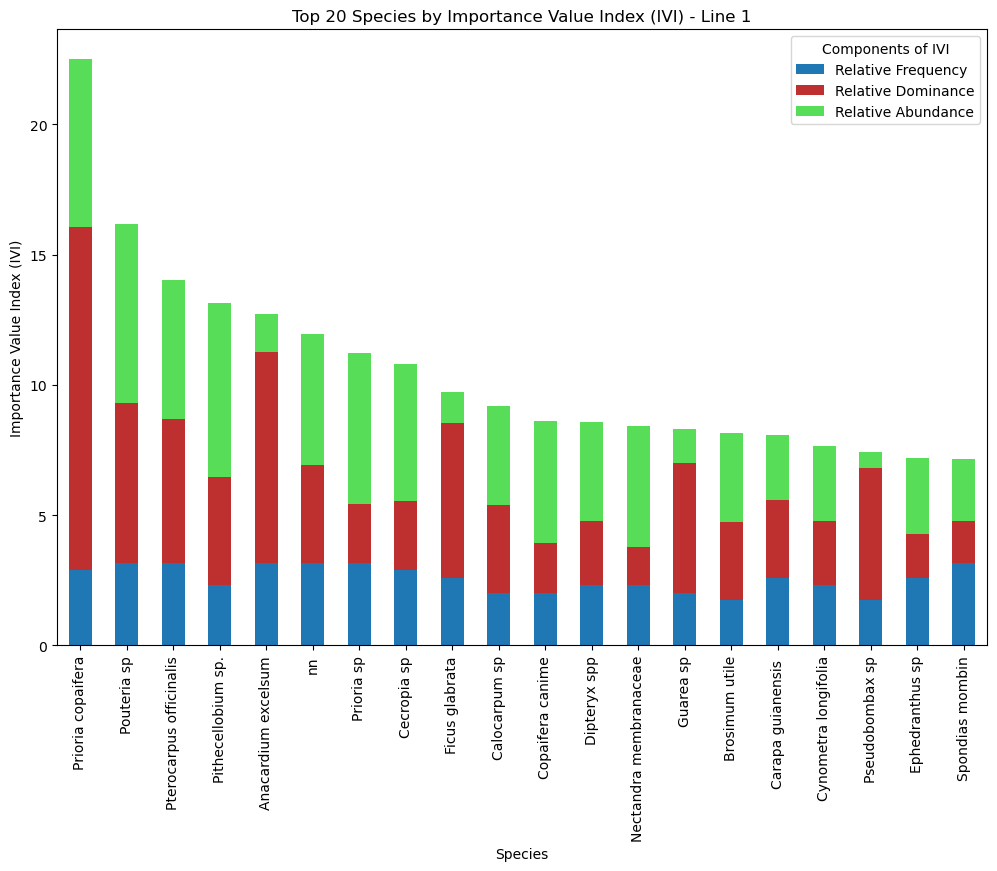

In [40]:
#Let's plot the top 20 species by IVI
#In this case we need a stacked bar plot that combines the three components of IVI
plt.figure(figsize=(10,6))
ax = top20_ivi1[['Fr', 'Do', 'Ab']].plot(
    kind='bar',
    stacked=True,
    figsize=(12,8),
    color=[color_ivi['Fr'], color_ivi['Do'], color_ivi['Ab']]
)
plt.xlabel('Species')
plt.ylabel('Importance Value Index (IVI)')
plt.title('Top 20 Species by Importance Value Index (IVI) - Line 1')
plt.legend(title='Components of IVI', loc='upper right', labels=[dict_ivi[color_ivi] for color_ivi in ['Fr', 'Do', 'Ab']])

In [36]:
# Helper to compute IVI for a given line dataframe

def compute_ivi(line_df):
    # Frequency: number of unique plots per species, then relative frequency
    fr = line_df.pivot_table(index='Scientific name', values='Plot', aggfunc='nunique')
    fr = fr[fr['Plot'] > 0]
    pl = line_df['Plot'].nunique() if 'Plot' in line_df.columns else 0
    fr['Freq'] = (fr['Plot'] / pl) * 100 if pl > 0 else 0
    freq_sum = fr['Freq'].sum() if pl > 0 else 0
    fr['Fr'] = (fr['Freq'] / freq_sum) * 100 if freq_sum > 0 else 0

    # Dominance: sum basal area and compute relative dominance
    do = line_df.pivot_table(index='Scientific name', values='Basal area [m2]', aggfunc='sum')
    do = do[do['Basal area [m2]'] != 0]
    g = do['Basal area [m2]'].sum()
    do['Do'] = (do['Basal area [m2]'] / g) * 100 if g > 0 else 0

    # Abundance: count individuals and compute relative abundance
    ab = line_df.groupby('Scientific name').size().to_frame(name='Abundance')
    ab = ab[ab['Abundance'] > 0]
    n = ab['Abundance'].sum()
    ab['Ab'] = (ab['Abundance'] / n) * 100 if n > 0 else 0

    # Join components and compute IVI
    ivi = fr.join(do).join(ab)
    for col in ['Fr', 'Do', 'Ab']:
        if col in ivi.columns:
            ivi[col] = ivi[col].fillna(0)
        else:
            ivi[col] = 0

    ivi['IVI'] = ivi['Fr'] + ivi['Do'] + ivi['Ab']
    return ivi.sort_values(by='IVI', ascending=False)

# Compute IVI for lines 1-7
ivi1 = compute_ivi(line1)
ivi2 = compute_ivi(line2)
ivi3 = compute_ivi(line3)
ivi4 = compute_ivi(line4)
ivi5 = compute_ivi(line5)
ivi6 = compute_ivi(line6)
ivi7 = compute_ivi(line7)

# Print quick checks
for i, ivi_df in enumerate([ivi1, ivi2, ivi3, ivi4, ivi5, ivi6, ivi7], start=1):
    print(f"Line {i} - IVI sum: {ivi_df['IVI'].sum():.2f}")

# Show top 20 species by IVI for each line
print('\nTop species by IVI (Line 1):')
print(ivi1.head(20))
print('\nTop species by IVI (Line 2):')
print(ivi2.head(20))
print('\nTop species by IVI (Line 3):')
print(ivi3.head(20))
print('\nTop species by IVI (Line 4):')
print(ivi4.head(20))
print('\nTop species by IVI (Line 5):')
print(ivi5.head(20))
print('\nTop species by IVI (Line 6):')
print(ivi6.head(20))
print('\nTop species by IVI (Line 7):')
print(ivi7.head(20))

Line 1 - IVI sum: 300.00
Line 2 - IVI sum: 300.00
Line 3 - IVI sum: 300.00
Line 4 - IVI sum: 300.00
Line 5 - IVI sum: 300.00
Line 6 - IVI sum: 300.00
Line 7 - IVI sum: 300.00

Top species by IVI (Line 1):
                         Plot       Freq        Fr  Basal area [m2]  \
Scientific name                                                       
Prioria copaifera          10  83.333333  2.890173        28.932947   
Pouteria sp                11  91.666667  3.179191        13.427027   
Pterocarpus officinalis    11  91.666667  3.179191        12.101714   
Pithecellobium sp.          8  66.666667  2.312139         9.112878   
Anacardium excelsum        11  91.666667  3.179191        17.725720   
nn                         11  91.666667  3.179191         8.249006   
Prioria sp                 11  91.666667  3.179191         4.913000   
Cecropia sp                10  83.333333  2.890173         5.826350   
Ficus glabrata              9  75.000000  2.601156        13.069839   
Calocarpum sp 

C:\Users\migue\AppData\Local\Temp\ipykernel_12580\1496742402.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  fr = line_df.pivot_table(index='Scientific name', values='Plot', aggfunc='nunique')
C:\Users\migue\AppData\Local\Temp\ipykernel_12580\1496742402.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  do = line_df.pivot_table(index='Scientific name', values='Basal area [m2]', aggfunc='sum')
C:\Users\migue\AppData\Local\Temp\ipykernel_12580\1496742402.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future 

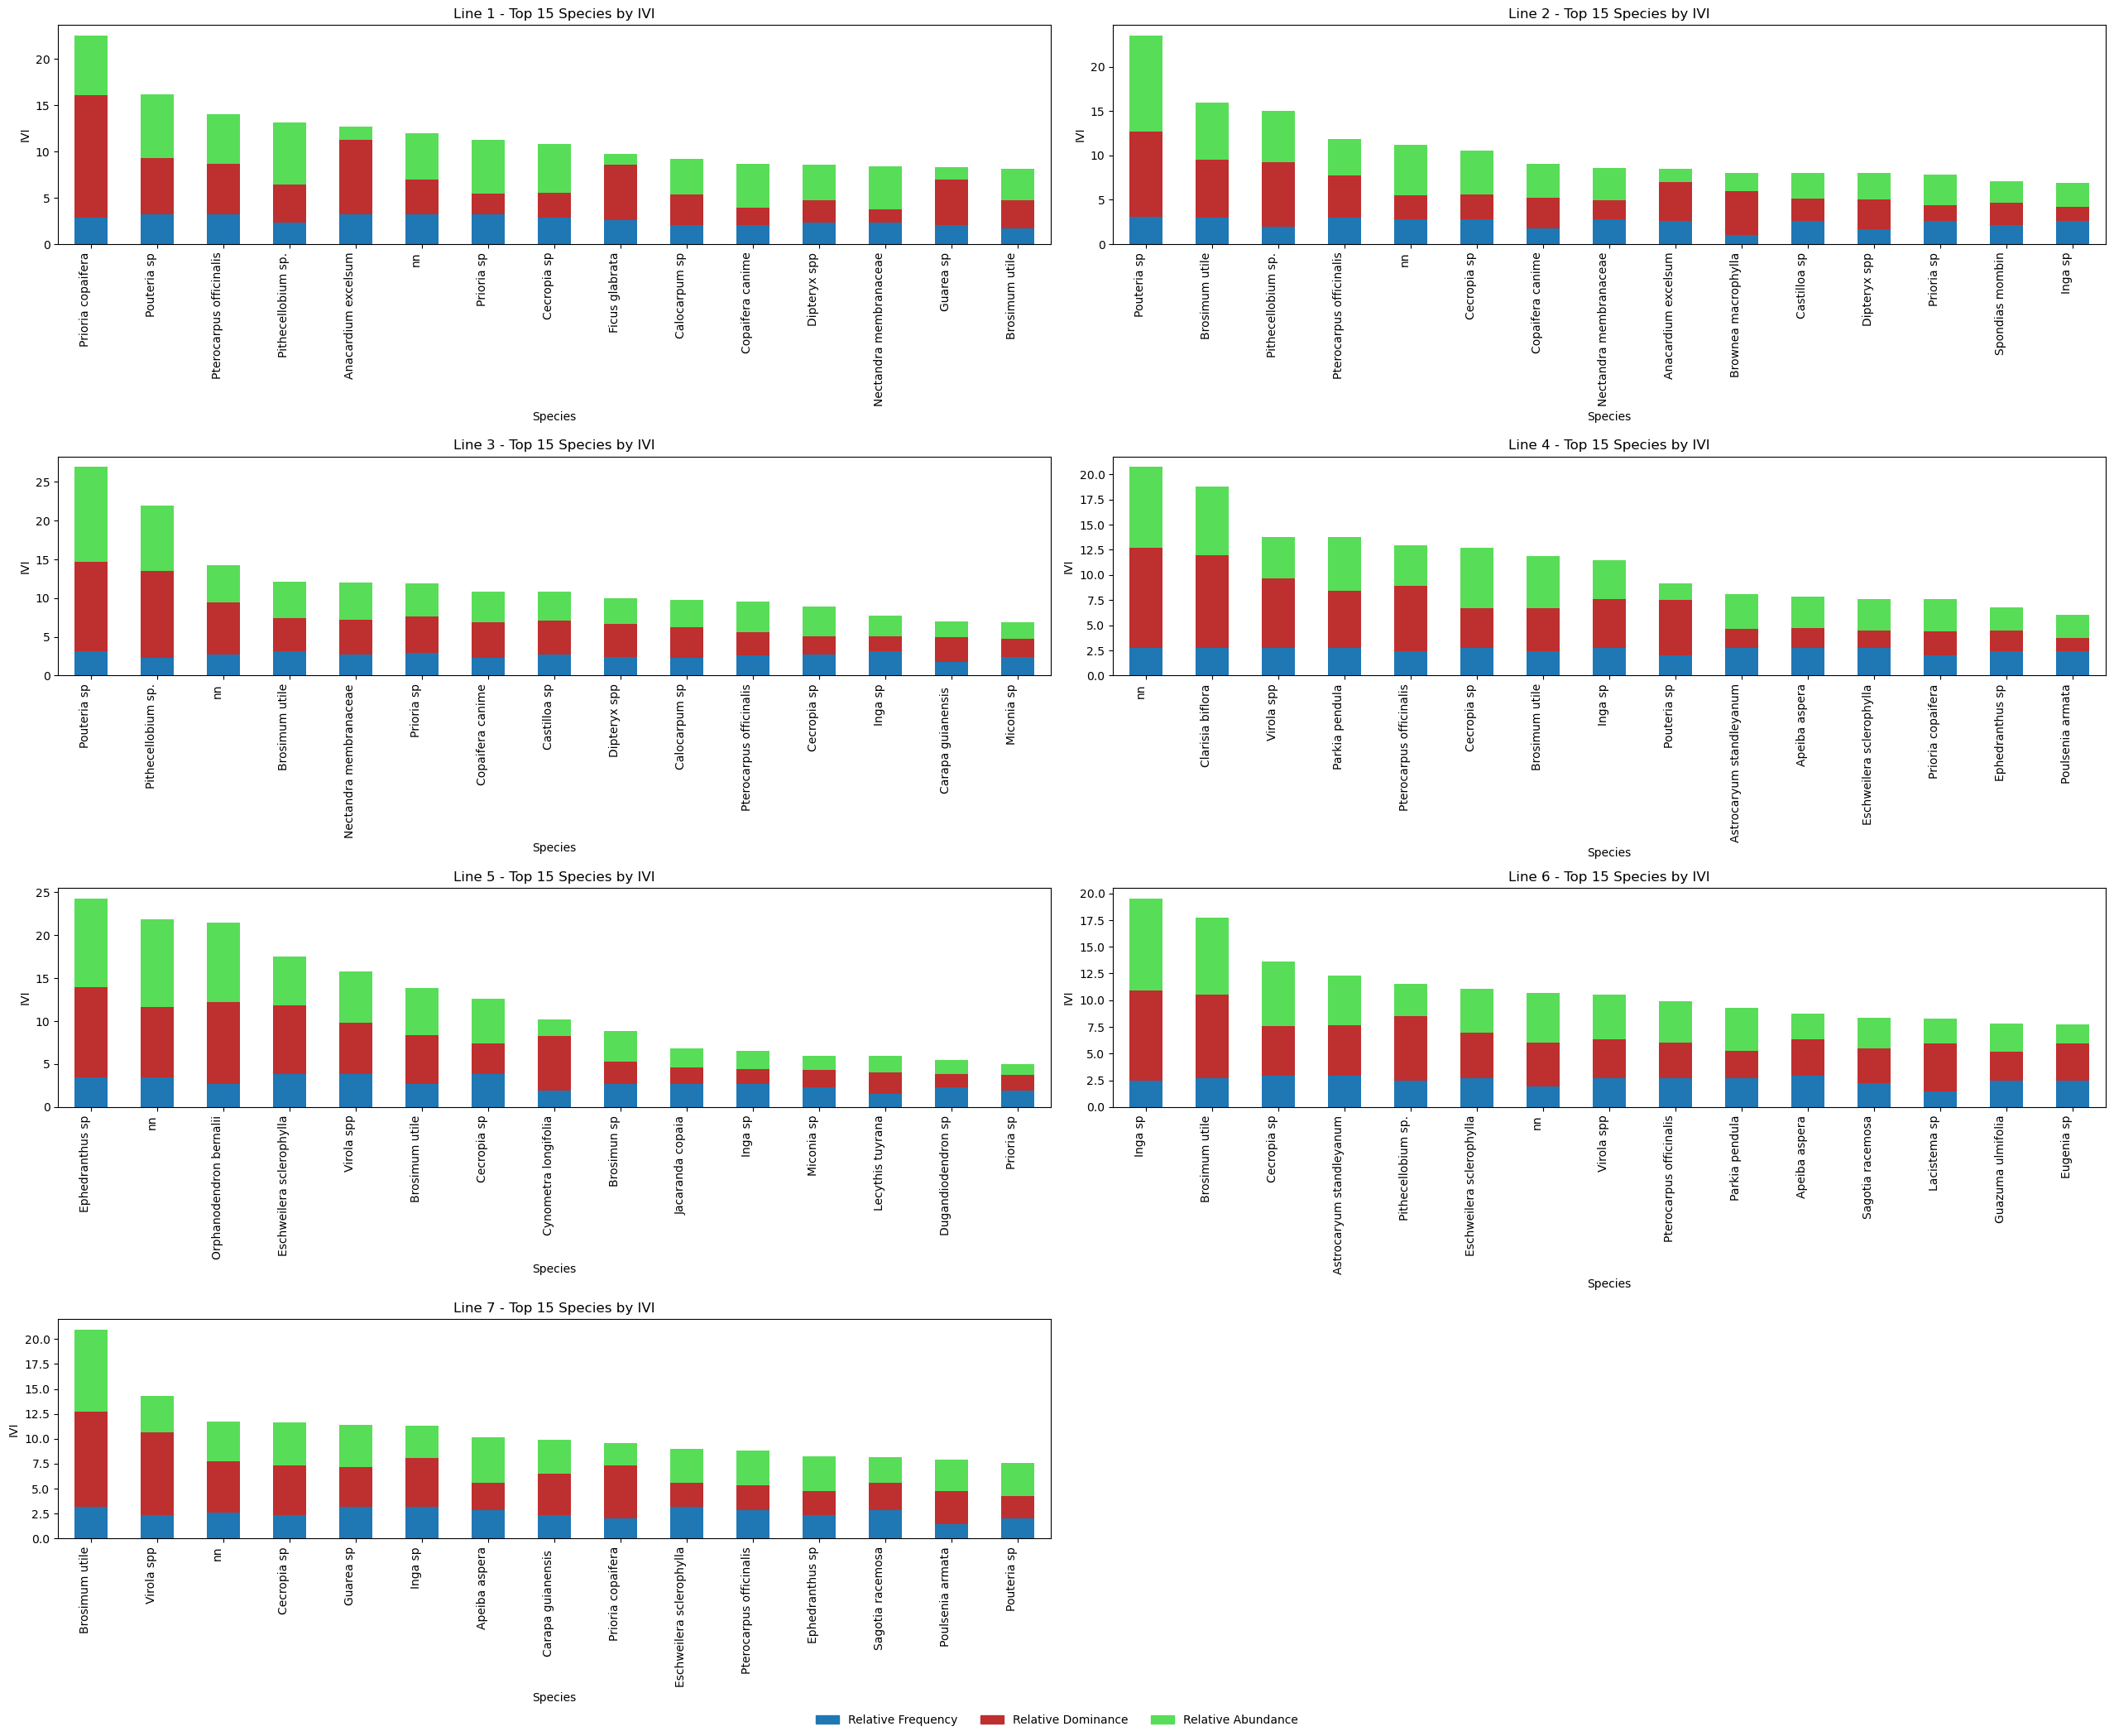

In [44]:
# Stacked IVI bar charts per line (4x2 matrix) — colors from color_ivi
top_n = 15
fig, axes = plt.subplots(4, 2, figsize=(27, 21))
axes = axes.flatten()

ivi_list = [ivi1, ivi2, ivi3, ivi4, ivi5, ivi6, ivi7]
for i, ivi_df in enumerate(ivi_list):
    ax = axes[i]
    if ivi_df.empty:
        ax.set_visible(False)
        continue
    plot_df = ivi_df[["Fr", "Do", "Ab"]].head(top_n)
    plot_df.plot(kind='bar', stacked=True, ax=ax, color=[color_ivi['Fr'], color_ivi['Do'], color_ivi['Ab']], legend=False)
    ax.set_title(f'Line {i+1} - Top {min(top_n, len(plot_df))} Species by IVI')
    ax.set_xlabel('Species')
    ax.set_ylabel('IVI')
    ax.tick_params(axis='x', rotation=90)
    ax.set_xticklabels(plot_df.index, rotation=90, ha='right')

# Legend once on the last subplot column
handles = [plt.Rectangle((0,0),1,1, color=color_ivi[k]) for k in ['Fr','Do','Ab']]
labels = [dict_ivi[k] for k in ['Fr','Do','Ab']]
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)

# Hide unused subplot (8th)
axes[7].set_visible(False)
plt.tight_layout(rect=[0,0.01,0.95,1])
plt.show()

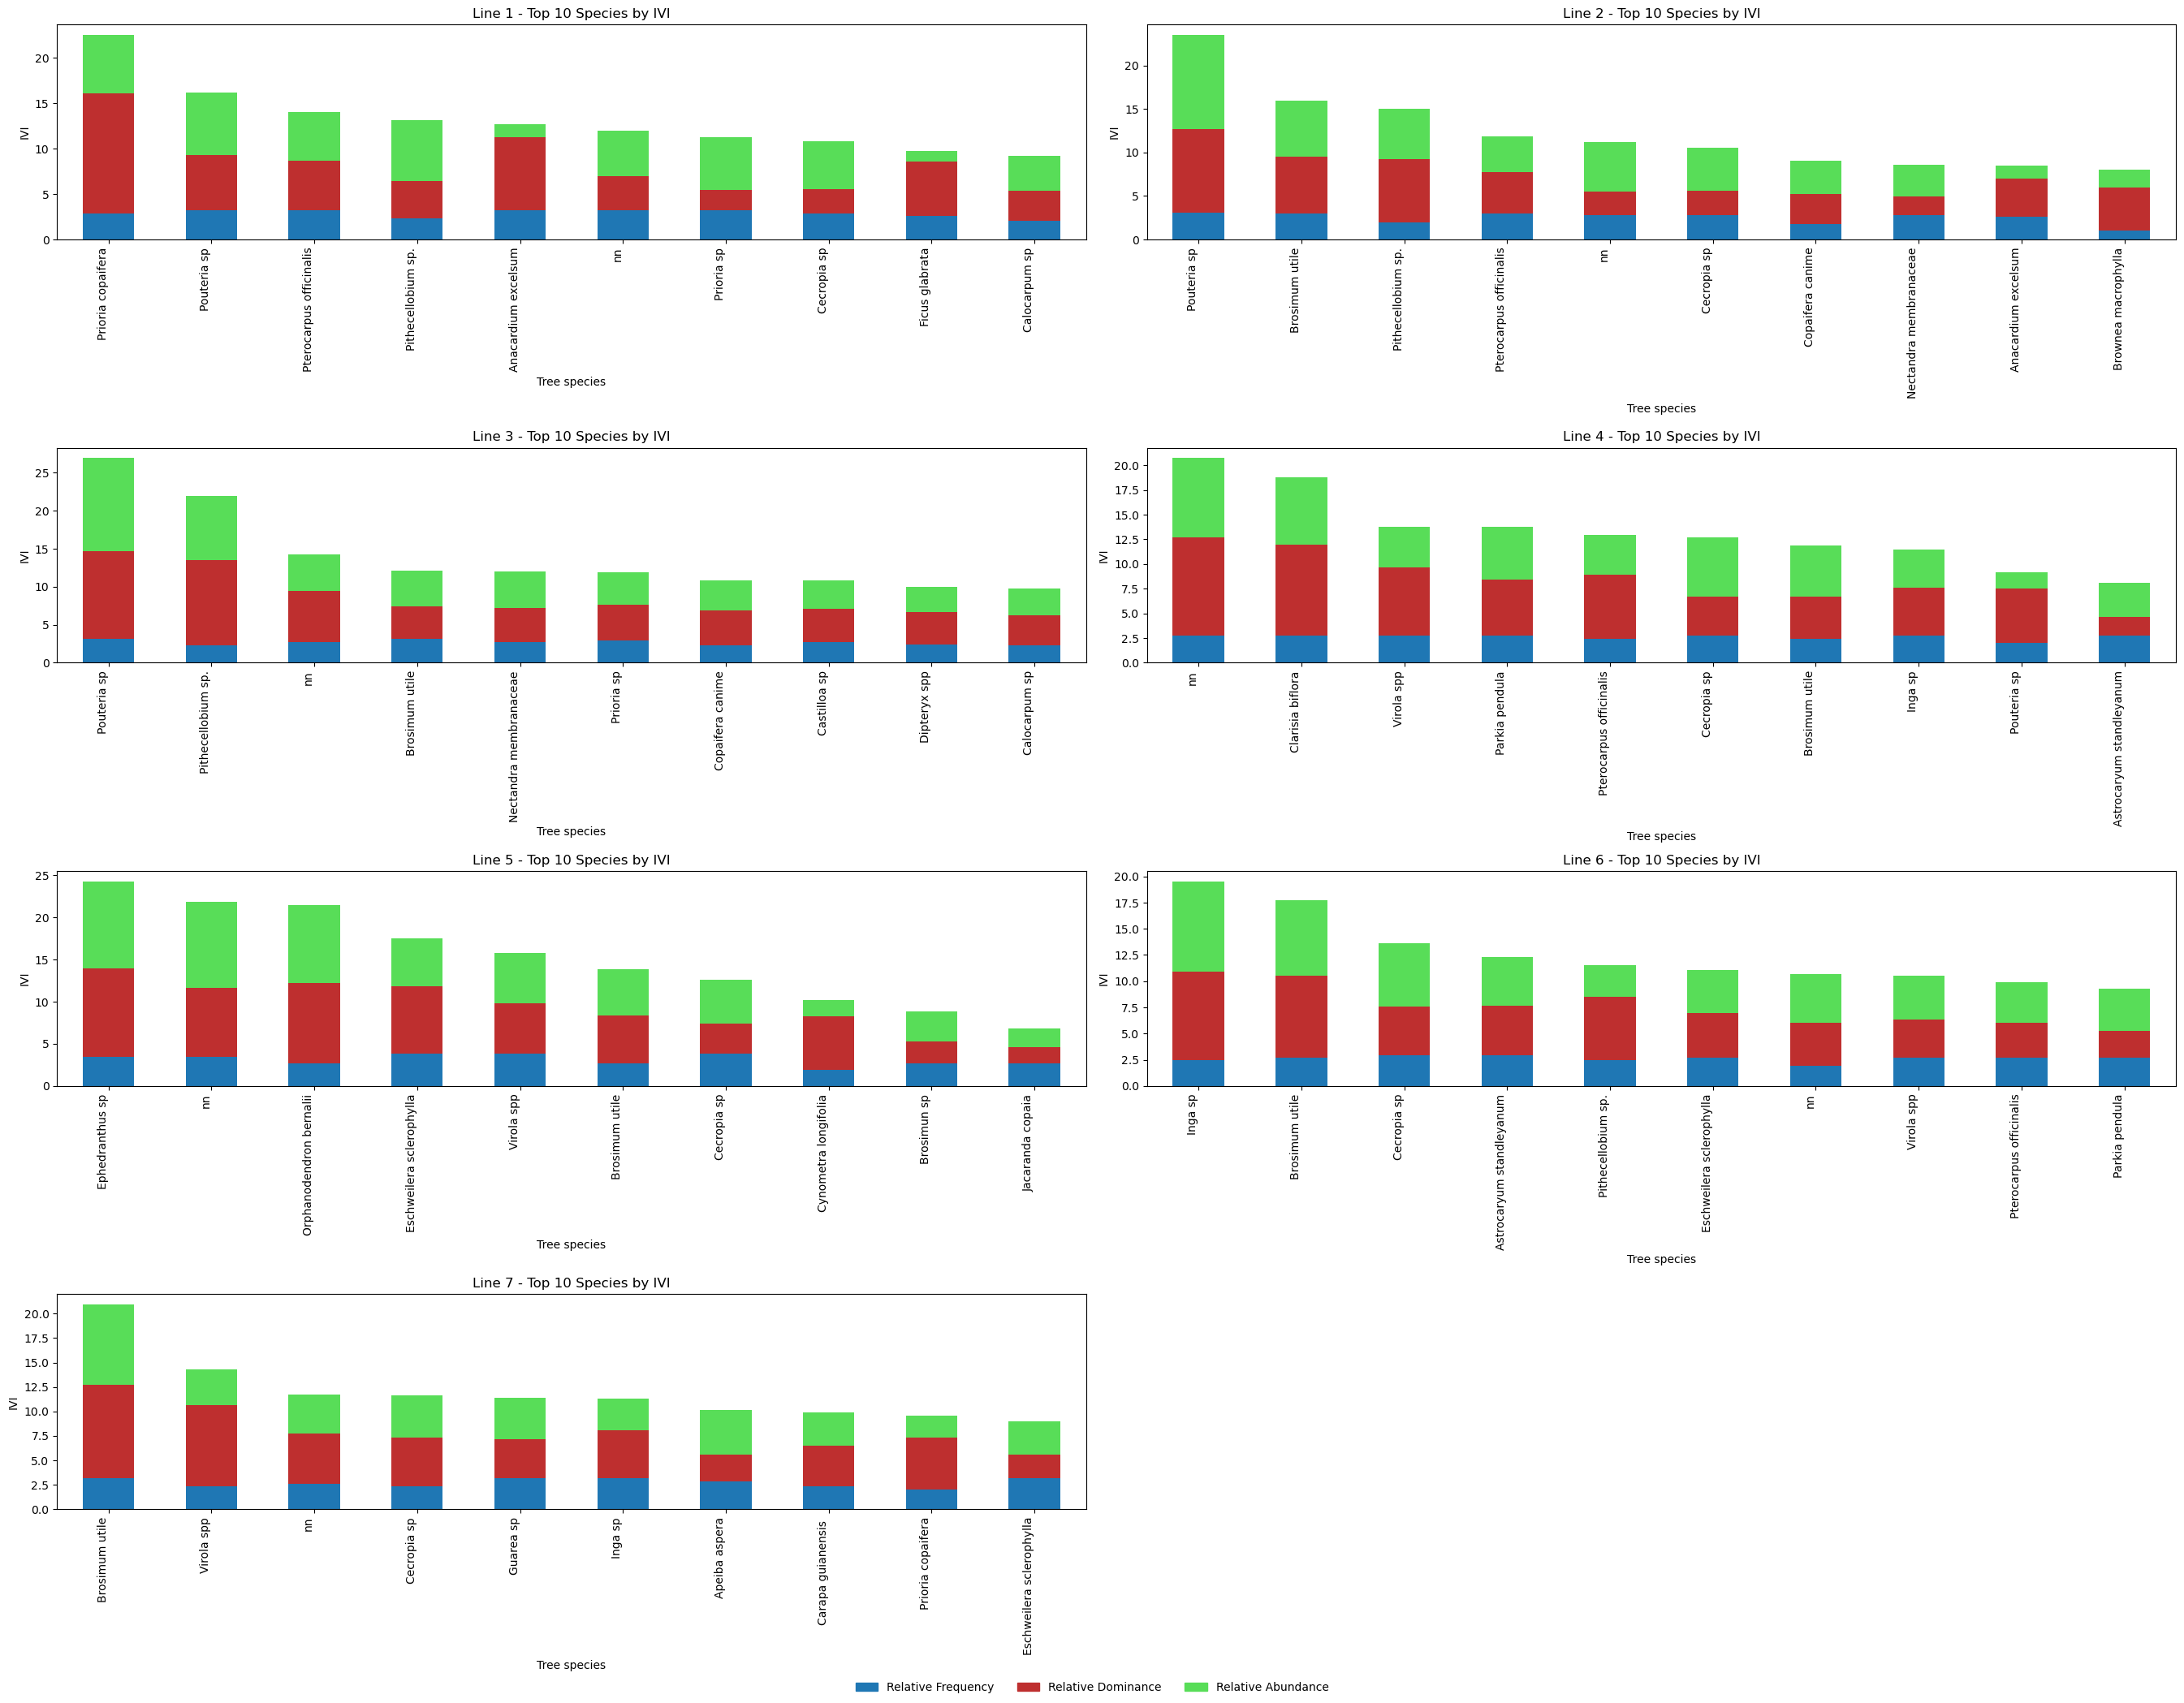

In [45]:
# Stacked IVI bar charts per line (4x2 matrix) — colors from color_ivi
top_n = 10
fig, axes = plt.subplots(4, 2, figsize=(27, 21))
axes = axes.flatten()

ivi_list = [ivi1, ivi2, ivi3, ivi4, ivi5, ivi6, ivi7]
for i, ivi_df in enumerate(ivi_list):
    ax = axes[i]
    if ivi_df.empty:
        ax.set_visible(False)
        continue
    plot_df = ivi_df[["Fr", "Do", "Ab"]].head(top_n)
    plot_df.plot(kind='bar', stacked=True, ax=ax, color=[color_ivi['Fr'], color_ivi['Do'], color_ivi['Ab']], legend=False)
    ax.set_title(f'Line {i+1} - Top {min(top_n, len(plot_df))} Species by IVI')
    ax.set_xlabel('Tree species')
    ax.set_ylabel('IVI')
    ax.tick_params(axis='x', rotation=90)
    ax.set_xticklabels(plot_df.index, rotation=90, ha='right')

# Legend once on the last subplot column
handles = [plt.Rectangle((0,0),1,1, color=color_ivi[k]) for k in ['Fr','Do','Ab']]
labels = [dict_ivi[k] for k in ['Fr','Do','Ab']]
fig.legend(handles, labels, loc='lower center', ncol=3, frameon=False)

# Hide unused subplot (8th)
axes[7].set_visible(False)
plt.tight_layout(rect=[0,0.01,1,1])
plt.show()